In [ ]:
import sys
import pypsa
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sys.path.append(str(Path.cwd().parent / 'scripts'))
from _tyndp_helpers import _extract_scenario_values, _extract_scenario_values_rowwise

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


In [3]:
years = [2030, 2035, 2040]
path = Path.cwd().parent / 'results' / 'networks' 

#### Transport

In [4]:
valpath = Path.cwd().parent / 'data' / 'TYNDP_2024-Scenario-Report-Data-Figures_240522.xlsx'

In [5]:
# ---------------------------------------------------------------------------
# Final electricity demand per sector, EU27 (TWh)
# Sheet: '6-'  |  Row labels: 'Residential & Tertiary', 'Transport', 'Industry'
# ---------------------------------------------------------------------------

def final_electricity_residential_tertiary(path):
    return _extract_scenario_values(path, sheet_name='6-', row_label='Residential & Tertiary')


def final_electricity_transport(path):
    return _extract_scenario_values(path, sheet_name='6-', row_label='Transport')


def final_electricity_industry(path):
    return _extract_scenario_values(path, sheet_name='6-', row_label='Industry')


# ---------------------------------------------------------------------------
# Methane demand per sector, EU27 (TWh)
# Sheet: '8-'  |  Row labels (top table): 'Residential&Tertiary', 'Power Generation', 'Industry'
# ---------------------------------------------------------------------------

def methane_residential_tertiary(path):
    # Note: in the sheet, it's "Residential&Tertiary" (no spaces around &)
    return _extract_scenario_values(path, sheet_name='8-', row_label='Residential&Tertiary')


def power_generation_methane(path):
    return _extract_scenario_values(path, sheet_name='8-', row_label='Power Generation')


def methane_industry_energetic(path):
    return _extract_scenario_values(path, sheet_name='8-', row_label='Industry')


def methane_industry_nonenergetic(path):
    return _extract_scenario_values(path, sheet_name='8-', row_label='Non-energy use')


# ---------------------------------------------------------------------------
# Energy sources for District Heating, EU27 (TWh) – Methane only
# Sheet: '12-'  |  Row label: 'Methane'
# ---------------------------------------------------------------------------


def district_heating_methane(path):
    return _extract_scenario_values(path, sheet_name='12-', row_label='Methane')
# ---------------------------------------------------------------------------
# Primary energy supply mix, EU27 (TWh)
# Sheet: '19-'  |  Row label: 'Natural gas****', 'Oil', 'Coal', 'Biomass', 'Nuclear', 'Solar', 'Wind'
# ---------------------------------------------------------------------------

def methane_primary_total(path):
    return _extract_scenario_values(path, sheet_name='19-', row_label='Natural gas****')

def oil_primary_total(path):
    return _extract_scenario_values(path, sheet_name='19-', row_label='Oil')

def coal_primary_total(path):
    return _extract_scenario_values(path, sheet_name='19-', row_label='Coal')

def biomass_primary_total(path):
    return _extract_scenario_values(path, sheet_name='19-', row_label='Biomass')

def nuclear_primary_total(path):
    return _extract_scenario_values(path, sheet_name='19-', row_label='Nuclear')

def solar_primary_total(path):
    return _extract_scenario_values(path, sheet_name='19-', row_label='Solar')

def wind_primary_total(path):
    return _extract_scenario_values(path, sheet_name='19-', row_label='Wind')

# ---------------------------------------------------------------------------
# Power capacity mix, EU27 (GW)
# Sheet: '25-'  |  Row label: Gas, Solar, Wind Onshore, Wind Offshore, Nuclear, Battery
# ---------------------------------------------------------------------------

def gas_power_capacity_mix(path):
    return _extract_scenario_values_rowwise(path, '25-', 'Methane')

def solar_power_capacity_mix(path):
    return _extract_scenario_values_rowwise(path, '25-', 'Solar')

def wind_onshore_power_capacity_mix(path):
    return _extract_scenario_values_rowwise(path, '25-', 'Wind Onshore')

def wind_offshore_power_capacity_mix(path):
    return _extract_scenario_values_rowwise(path, '25-', 'Wind Offshore')

def nuclear_power_capacity_mix(path):
    return _extract_scenario_values_rowwise(path, '25-', 'Nuclear')

def battery_power_capacity_mix(path):
    return _extract_scenario_values_rowwise(path, '25-', 'Battery')

# ---------------------------------------------------------------------------
# Power generation mix, EU27 (TWh)
# Sheet: '26-'  |  Row label: Gas, Solar, Wind Onshore, Wind Offshore, Nuclear, Battery
# ---------------------------------------------------------------------------

def gas_power_generation_mix(path):
    return _extract_scenario_values_rowwise(path, '26-', 'Methane****')

def solar_power_generation_mix(path):
    return _extract_scenario_values_rowwise(path, '26-', 'Solar**')

def wind_onshore_power_generation_mix(path):
    return _extract_scenario_values_rowwise(path, '26-', 'Wind Onshore**')

def wind_offshore_power_generation_mix(path):
    return _extract_scenario_values_rowwise(path, '26-', 'Wind Offshore**')

def nuclear_power_generation_mix(path):
    return _extract_scenario_values_rowwise(path, '26-', 'Nuclear')

def battery_power_generation_mix(path):
    return _extract_scenario_values_rowwise(path, '26-', 'Battery')

# ---------------------------------------------------------------------------
# Domestic gas production, EU27 (TWh)
# Sheet: '31-'  |  Row label: 'Natural gas (unabated)', 'Biomethane', 'Hydrogen (Green)', 'Hydrogen (Blue)', 'Hydrogen (Grey)', 'Synthetic methane'
# ---------------------------------------------------------------------------

def methane_domestic_production(path):
    return _extract_scenario_values(path, sheet_name='31-', row_label='Natural gas (unabated)')

def biomethane_domestic_production(path):
    return _extract_scenario_values(path, sheet_name='31-', row_label='Biomethane')

def green_hydrogen_domestic_production(path):
    return _extract_scenario_values(path, sheet_name='31-', row_label='Hydrogen (Green)')

def blue_hydrogen_domestic_production(path):
    return _extract_scenario_values(path, sheet_name='31-', row_label='Hydrogen (Blue)')

def grey_hydrogen_domestic_production(path):
    return _extract_scenario_values(path, sheet_name='31-', row_label='Hydrogen (Grey)')

def synthetic_gas_domestic_production(path):
    return _extract_scenario_values(path, sheet_name='31-', row_label='Synthetic methane')

# ---------------------------------------------------------------------------
# Methane Supply for EU27 (TWh)
# Sheet: '32-'  |  Row label: 'Natural gas (Import)', 'Natural gas (Domestic)', 'Biomethane (Import)', 'Biomethane (Domestic)', 'Synthetic methane (Import)', 'Synthetic methane (Domestic)'
# ---------------------------------------------------------------------------

def natural_gas_import(path):
    return _extract_scenario_values(path, sheet_name='32-', row_label='Natural gas (Import)')

def natural_gas_domestic(path):
    return _extract_scenario_values(path, sheet_name='32-', row_label='Natural gas (Domestic)')

def biomethane_import(path):
    return _extract_scenario_values(path, sheet_name='32-', row_label='Biomethane (Import)')

def biomethane_domestic(path):
    return _extract_scenario_values(path, sheet_name='32-', row_label='Biomethane (Domestic)')

def synthetic_methane_import(path):
    return _extract_scenario_values(path, sheet_name='32-', row_label='Synthetic methane (Import)')

def synthetic_methane_domestic(path):
    return _extract_scenario_values(path, sheet_name='32-', row_label='Synthetic methane (Domestic)')

In [6]:
def district_heating_methane(path):
    return _extract_scenario_values(path, sheet_name='12-', row_label='Methane')

def built_env(path):
    return _extract_scenario_values(path, sheet_name='12-', row_label='Electricity')

In [7]:
district_heating_methane(valpath)

{'National Trends': {2030: 196.0048935308436, 2040: 148.5758460816616},
 'Distributed Energy': {2040: 185.0084482341095, 2050: 101.83595123308632},
 'Global Ambition': {2040: 167.16060774403712, 2050: 84.25757358374423},
 'Reference': {}}

In [9]:
def homes_heating_percentage_methane(path):
    return _extract_scenario_values(path, sheet_name='13-', row_label='Methane boiler')

def homes_heating_percentage_heat_pump(path):
    return _extract_scenario_values(path, sheet_name='13-', row_label='Electric heat pump')

homes_heating_percentage_methane(valpath)

{'National Trends': {},
 'Distributed Energy': {2040: 0.1184262102322021, 2050: 0.03400090182364884},
 'Global Ambition': {2040: 0.13690433574359256, 2050: 0.04503805107028795},
 'Reference': {2019: 0.37195741242589125}}

In [9]:
synthetic_methane_import(valpath)

{'National Trends': {2030: 7.5, 2040: 15.0},
 'Distributed Energy': {2040: 3.6949723285098215, 2050: 17.271800424652046},
 'Global Ambition': {2040: 6.5914492930962805, 2050: 15.461453624933679},
 'Reference': {}}

In [12]:
# ns = {
#     year: pypsa.Network(path / f'base_s_50__168H-T-H-B-I-A-dist1_{year}.nc')
#     for year in years
# }
n = pypsa.Network(path / f'base_s_50__168H-T-H-B-I-A-dist1_2030.nc')

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [163]:
n.buses.carrier.unique()

array(['AC', 'none', 'co2', 'co2 stored', 'co2 sequestered', 'gas', 'H2',
       'battery', 'EV battery', 'oil', 'oil primary',
       'land transport oil', 'urban central heat', 'biogas',
       'solid biomass', 'unsustainable bioliquids', 'NH3', 'methanol',
       'solid biomass for industry', 'gas for industry',
       'industry methanol', 'naphtha for industry', 'non-sequestered HVC',
       'process emissions', 'coal', 'coal for industry',
       'shipping methanol', 'shipping oil', 'kerosene for aviation',
       'agriculture machinery oil', 'low voltage', 'home battery',
       'rural heat', 'urban decentral heat'], dtype=object)

In [ ]:
n.buses.links

In [ ]:
eu27_countries = [
    "AT", "BE", "BG", "HR", "CY", "CZ", "DK", "EE", "FI", "FR", "DE", "GR", "HU",
    "IE", "IT", "LV", "LT", "LU", "MT", "NL", "PL", "PT", "RO", "SK", "SI", "ES", "SE",
]
eu27_buses = n.buses.index[
    (n.buses.country.isin(eu27_countries)) &
    (n.buses.carrier == 'AC')
]
all_eu27_buses = n.buses.index[
    (n.buses.country.isin(eu27_countries))
]

In [18]:
demands = n.loads.index[
    (n.loads.bus.str.contains('urban decentral heat') | n.loads.bus.str.contains('rural heat')) &
    (n.loads.bus.isin(all_eu27_buses))
]
demands

Index(['FR5 0 low-temperature heat for industry', 'AT0 0 agriculture heat',
       'BE0 0 agriculture heat', 'BG0 0 agriculture heat',
       'CZ0 0 agriculture heat', 'DE0 0 agriculture heat',
       'DE0 1 agriculture heat', 'DE0 2 agriculture heat',
       'DE0 3 agriculture heat', 'DE0 4 agriculture heat',
       ...
       'PT0 0 rural heat', 'PT0 0 urban decentral heat', 'RO0 0 rural heat',
       'RO0 0 urban decentral heat', 'SE1 0 rural heat',
       'SE1 0 urban decentral heat', 'SI0 0 rural heat',
       'SI0 0 urban decentral heat', 'SK0 0 rural heat',
       'SK0 0 urban decentral heat'],
      dtype='object', name='Load', length=118)

In [21]:
varying = demands.intersection(n.loads_t.p_set.columns)
static = demands.difference(varying)

p_set_static = pd.DataFrame({i: [n.loads.loc[i, 'p_set']] * len(n.snapshots) for i in static}, index=n.snapshots)
p_set_varying = n.loads_t.p_set.loc[:, varying]

In [24]:
def to_ac_bus(x):
    return ' '.join(x.split(' ')[:2])

In [30]:
total = (p_set_varying.T.groupby(to_ac_bus).sum() + p_set_static.T.groupby(to_ac_bus).sum()).T

In [33]:
existing = pd.read_csv(Path.cwd().parent / 'resources' / 'existing_heating_distribution_base_s_50_2030.csv', header=[0, 1], index_col=0).loc[eu27_buses]
idx = pd.IndexSlice

res = existing.loc[:, idx['residential urban decentral', :]]
res.columns = res.columns.get_level_values(1)
ser = existing.loc[:, idx['services urban decentral', :]]
ser.columns = ser.columns.get_level_values(1)

existing = (res + ser)['gas boiler'] # using existing gas boiler distribution to approximate district heat gas boiler distribution

In [35]:
shares = existing / existing.sum()

In [37]:
w = n.snapshot_weightings.generators.iloc[0]

In [42]:
total.sum().sum() * w * 1e-6

2106.27159847749

In [162]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'solid biomass for industry',
       'gas for industry', 'H2 for industry', 'industry methanol',
       'naphtha for industry', 'low-temperature heat for industry',
       'industry electricity', 'process emissions', 'NH3',
       'coal for industry', 'shipping methanol', 'shipping oil',
       'kerosene for aviation', 'agriculture electricity',
       'agriculture heat', 'agriculture machinery electric',
       'agriculture machinery oil', 'rural heat', 'urban decentral heat'],
      dtype=object)

In [161]:
methane_industry_energetic(valpath)

{'National Trends': {2030: 888.188982683603, 2040: 595.9978468590181},
 'Distributed Energy': {2040: 477.3971818688508, 2050: 248.66383725068562},
 'Global Ambition': {2040: 553.2439756265355, 2050: 306.10857628850994},
 'Reference': {2019: 1034.0050852378477}}

In [43]:
n.links.loc[n.links.carrier.str.contains('gas boiler'), 'carrier'].unique()

array(['urban central gas boiler', 'rural gas boiler',
       'urban decentral gas boiler'], dtype=object)

In [41]:
target = 0.20
factor = target * total.sum().sum() * w / shares.sum()
(factor * shares * 1e-6).sum()

421.25431969549805

In [148]:
# m = pypsa.Network(Path.cwd().parent / 'resources' / 'networks' / f'base_s_50__168H-T-H-B-I-A-dist1_2030_NT.nc')
m = pypsa.Network(Path.cwd().parent / 'results' / 'networks' / f'base_s_50__168H-T-H-B-I-A-dist1_2030_NT.nc')

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_NT.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores



Random non-exceeding case: XK0 0 urban decentral gas boiler


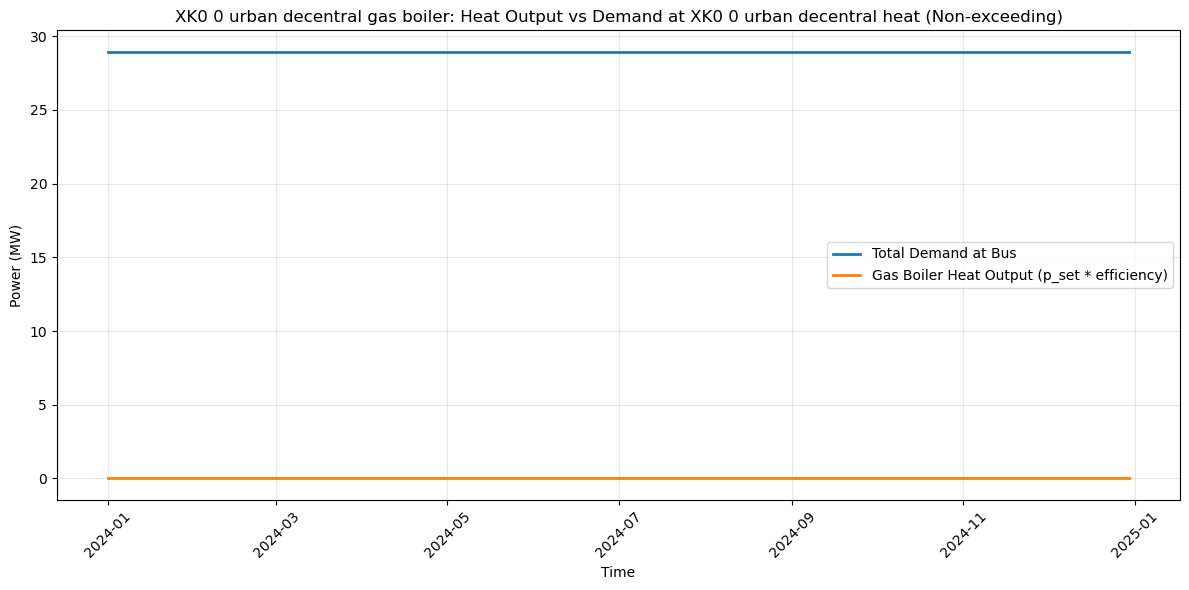

In [149]:
# Check if gas boiler p_set * efficiency exceeds demand at any timestep
gas_boiler_links = m.links.index[m.links.carrier.str.contains('gas boiler')]

# Track if we've plotted a random non-exceeding case
plotted_random = False
random_link_to_plot = None

for link_name in gas_boiler_links[::-1]:
    link = m.links.loc[link_name]
    bus1 = link.bus1
    efficiency = link.efficiency
    
    # Get p_set for this link
    if link_name in m.links_t.p_set.columns:
        p_set = m.links_t.p_set[link_name]
    else:
        p_set = pd.Series(link.p_set, index=m.snapshots)
    
    # Calculate heat output
    heat_output = p_set * efficiency
    
    # Get demand at bus1
    loads_at_bus = m.loads.index[m.loads.bus == bus1]
    total_demand = pd.Series(0.0, index=m.snapshots)
    
    for load_name in loads_at_bus:
        if load_name in m.loads_t.p_set.columns:
            total_demand += m.loads_t.p_set[load_name]
        else:
            total_demand += m.loads.loc[load_name, 'p_set']
    
    # Check if heat output exceeds demand at any timestep
    exceeds = heat_output > total_demand
    if exceeds.any():
        max_excess = (heat_output - total_demand).max()
        print(f'{link_name}: Heat output exceeds demand at {exceeds.sum()} timesteps. Max excess: {max_excess:.2f} MW')
        
        # Plot the timeseries
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(m.snapshots, total_demand, label='Total Demand at Bus', linewidth=2)
        ax.plot(m.snapshots, heat_output, label='Gas Boiler Heat Output (p_set * efficiency)', linewidth=2)
        ax.set_xlabel('Time')
        ax.set_ylabel('Power (MW)')
        ax.set_title(f'{link_name}: Heat Output vs Demand at {bus1}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        # Store the first non-exceeding link for random plotting
        if not plotted_random and random_link_to_plot is None:
            random_link_to_plot = (link_name, bus1, heat_output, total_demand)

# Plot a random bus where the if clause was not triggered
if random_link_to_plot is not None:
    link_name, bus1, heat_output, total_demand = random_link_to_plot
    print(f'\nRandom non-exceeding case: {link_name}')
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(m.snapshots, total_demand, label='Total Demand at Bus', linewidth=2)
    ax.plot(m.snapshots, heat_output, label='Gas Boiler Heat Output (p_set * efficiency)', linewidth=2)
    ax.set_xlabel('Time')
    ax.set_ylabel('Power (MW)')
    ax.set_title(f'{link_name}: Heat Output vs Demand at {bus1} (Non-exceeding)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [150]:
def homes_heating_percentage_methane(path):
    return _extract_scenario_values(path, sheet_name='13-', row_label='Methane boiler')

In [151]:
methane_homes_heating_percentages = homes_heating_percentage_methane(valpath)
    
value_2040 = (methane_homes_heating_percentages['Global Ambition'][2040] + methane_homes_heating_percentages['Distributed Energy'][2040]) / 2

time_weight_2019 = (2030 - 2019) / (2040 - 2019)
target_share = methane_homes_heating_percentages['Reference'][2019] * (1 - time_weight_2019) + value_2040 * time_weight_2019

print(f'Target methane residential and services heating percentage: {target_share:.2%}')

target_share /= 100

Target methane residential and services heating percentage: 24.40%


In [152]:
m.links_t.p_set.columns[50:80]

Index(['ES6 0 rural gas boiler', 'FR0 0 rural gas boiler',
       'FR0 1 rural gas boiler', 'FR0 2 rural gas boiler',
       'FR0 3 rural gas boiler', 'FR0 4 rural gas boiler',
       'GR0 0 rural gas boiler', 'HR0 0 rural gas boiler',
       'HU0 0 rural gas boiler', 'IE3 0 rural gas boiler',
       'IT0 0 rural gas boiler', 'IT0 1 rural gas boiler',
       'IT4 0 rural gas boiler', 'LU0 0 rural gas boiler',
       'LV0 0 rural gas boiler', 'NL0 0 rural gas boiler',
       'PL0 0 rural gas boiler', 'PT0 0 rural gas boiler',
       'RO0 0 rural gas boiler', 'SE1 0 rural gas boiler',
       'SI0 0 rural gas boiler', 'SK0 0 rural gas boiler',
       'AT0 0 urban decentral gas boiler', 'BE0 0 urban decentral gas boiler',
       'BG0 0 urban decentral gas boiler', 'CZ0 0 urban decentral gas boiler',
       'DE0 0 urban decentral gas boiler', 'DE0 1 urban decentral gas boiler',
       'DE0 2 urban decentral gas boiler', 'DE0 3 urban decentral gas boiler'],
      dtype='object', name='Link')

In [154]:
gas_boiler = m.links.index[m.links.carrier.str.contains('gas boiler')]
(m.links_t.p0[gas_boiler].sum() * 168 / 1e6).sum()

920.7991740199451

In [158]:
m.links_t.p0[gas_boiler[1]].head()

snapshot
2024-01-01    435.049422
2024-01-08    605.401016
2024-01-15    558.999361
2024-01-22    422.453988
2024-01-29    409.278770
Name: AT0 0 urban central gas boiler, dtype: float64

In [157]:
m.links_t.p_set[gas_boiler[1]].head()

snapshot
2024-01-01    435.049422
2024-01-08    605.401016
2024-01-15    558.999361
2024-01-22    422.453988
2024-01-29    409.278770
Name: AT0 0 urban central gas boiler, dtype: float64

In [147]:
cols = m.links_t.p_set.columns.intersection(gas_boiler)
m.links_t.p_set[cols].sum().sum() * 168 / 1e6

722.3598199099893

In [141]:
m.links_t.p_set['AL0 urban central gas boiler']

KeyError: 'AL0 urban central gas boiler'

In [131]:
(m.links_t.p_set[gas_boiler].sum() * 168 / 1e6).sum()

KeyError: "['AL0 0 urban central gas boiler', 'BA0 0 urban central gas boiler', 'CH0 0 urban central gas boiler', 'FI1 0 urban central gas boiler', 'GB2 0 urban central gas boiler', 'GB2 1 urban central gas boiler', 'GB3 0 urban central gas boiler', 'LT0 0 urban central gas boiler', 'ME0 0 urban central gas boiler', 'MK0 0 urban central gas boiler', 'NO1 0 urban central gas boiler', 'RS0 0 urban central gas boiler', 'XK0 0 urban central gas boiler', 'AL0 0 rural gas boiler', 'AL0 0 urban decentral gas boiler', 'BA0 0 rural gas boiler', 'BA0 0 urban decentral gas boiler', 'CH0 0 rural gas boiler', 'CH0 0 urban decentral gas boiler', 'FI1 0 rural gas boiler', 'FI1 0 urban decentral gas boiler', 'FR5 0 rural gas boiler', 'FR5 0 urban decentral gas boiler', 'GB2 0 rural gas boiler', 'GB2 0 urban decentral gas boiler', 'GB2 1 rural gas boiler', 'GB2 1 urban decentral gas boiler', 'GB3 0 rural gas boiler', 'GB3 0 urban decentral gas boiler', 'LT0 0 rural gas boiler', 'LT0 0 urban decentral g

In [125]:
tt = 0

for context in ['urban decentral', 'rural']:

    demands = n.loads.index[
        (n.loads.bus.str.contains(context + ' heat')) &
        (n.loads.index.str.startswith(tuple(eu27_countries)))
    ]

    varying = demands.intersection(n.loads_t.p_set.columns)
    static = demands.difference(varying)

    p_set_static = pd.DataFrame({i: [n.loads.loc[i, 'p_set']] * len(n.snapshots) for i in static}, index=n.snapshots)
    p_set_varying = n.loads_t.p_set.loc[:, varying]

    total_tseries = p_set_varying.T.groupby(to_ac_bus).sum().add(p_set_static.T.groupby(to_ac_bus).sum(), fill_value=0).T
    tt += total_tseries.sum().sum() * w

tt / 1e6

2106.2715984774904

In [126]:
factor * shares

Bus
AT0 0    5.020981e+06
BE0 0    2.505861e+07
BG0 0    1.117388e+05
CZ0 0    6.264665e+06
DE0 0    1.484448e+07
DE0 1    4.707657e+06
DE0 2    2.783026e+07
DE0 3    9.610319e+06
DE0 4    2.565839e+07
DE0 5    1.195300e+07
DK0 0    2.582921e+06
DK1 0    1.526105e+06
EE0 0    1.438915e+05
ES0 0    3.598700e+07
ES6 0    6.813156e+05
FI1 0    0.000000e+00
FR0 0    2.334886e+07
FR0 1    1.398874e+07
FR0 2    5.763474e+06
FR0 3    9.202771e+06
FR0 4    5.110951e+06
FR5 0    0.000000e+00
GR0 0    1.641203e+06
HR0 0    4.534944e+06
HU0 0    1.387020e+07
IE3 0    2.628132e+06
IT0 0    2.904416e+07
IT0 1    4.558074e+07
IT4 0    5.807637e+05
LT0 0    0.000000e+00
LU0 0    6.701464e+05
LV0 0    9.529286e+05
NL0 0    7.106963e+07
PL0 0    4.591028e+06
PT0 0    2.933515e+06
RO0 0    8.395310e+06
SE1 0    8.211095e+05
SI0 0    2.121698e+05
SK0 0    4.332213e+06
Name: gas boiler, dtype: float64

In [127]:
factor

421254319.69549793

In [ ]:
existing

NameError: name 'existing' is not defined

In [ ]:
demands = n.

In [201]:
eu27_countries = [
    "AT",  # Austria
    "BE",  # Belgium
    "BG",  # Bulgaria
    "HR",  # Croatia
    "CY",  # Cyprus
    "CZ",  # Czechia
    "DK",  # Denmark
    "EE",  # Estonia
    "FI",  # Finland
    "FR",  # France
    "DE",  # Germany
    "GR",  # Greece
    "HU",  # Hungary
    "IE",  # Ireland
    "IT",  # Italy
    "LV",  # Latvia
    "LT",  # Lithuania
    "LU",  # Luxembourg
    "MT",  # Malta
    "NL",  # Netherlands
    "PL",  # Poland
    "PT",  # Portugal
    "RO",  # Romania
    "SK",  # Slovakia
    "SI",  # Slovenia
    "ES",  # Spain
    "SE",  # Sweden
]
eu27_buses = ns[2030].buses.index[
    (ns[2030].buses.country.isin(eu27_countries)) &
    (ns[2030].buses.carrier == 'AC')
]
all_eu27_buses = ns[2030].buses.index[
    (ns[2030].buses.country.isin(eu27_countries))
]

In [202]:
tyndp_colors = {
    'National Trends': '#fe4a49',
    'Distributed Energy': '#2ab7ca',
    'Global Ambition': '#fed766',
}

def darken_color(color, factor=0.7):
    rgb = mcolors.to_rgb(color)
    return tuple(c * factor for c in rgb)

#### Land Transport

In [203]:
tyndp_ev_demand = final_electricity_transport(valpath)

ev_load = list()
ice_load = list()

w = n.snapshot_weightings.generators.iloc[0]

for year in years:

    evs = ns[year].loads.index[(ns[year].loads.carrier == 'land transport EV') & (ns[year].loads.bus.isin(all_eu27_buses))]
    ices = ns[year].loads.index[(ns[year].loads.carrier == 'land transport oil') & (ns[year].loads.bus.isin(all_eu27_buses))]

    ev_load.append(ns[year].loads_t.p_set.loc[:, evs].sum().sum() * w * 1e-6)
    ice_load.append(ns[year].loads_t.p_set.loc[:, ices].sum().sum() * w * 1e-6)

In [204]:
def get_ylimmax(args):
    ylimmax = 0

    for arg in args:
        if isinstance(arg, list):
            ylimmax = max(ylimmax, max(arg))
        elif isinstance(arg, dict):
            ylimmax = max(ylimmax, max(
                [arg['National Trends'][2030], arg['National Trends'][2040], arg['Distributed Energy'][2040], arg['Global Ambition'][2040]]
                )
            )
    return ylimmax

In [205]:
def add_tyndp_legend(axs):
    # Add legend for TYNDP scenarios
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', markerfacecolor=tyndp_colors['National Trends'], 
            markeredgecolor=darken_color(tyndp_colors['National Trends']), 
            markersize=10, color='w', label='National Trends', alpha=0.5),
        Line2D([0], [0], marker='o', markerfacecolor=tyndp_colors['Distributed Energy'], 
            markeredgecolor=darken_color(tyndp_colors['Distributed Energy']), 
            markersize=10, color='w', label='Distributed Energy', alpha=0.5),
        Line2D([0], [0], marker='o', markerfacecolor=tyndp_colors['Global Ambition'], 
            markeredgecolor=darken_color(tyndp_colors['Global Ambition']), 
            markersize=10, color='w', label='Global Ambition', alpha=0.5),
    ]
    axs[-1].legend(
        title='TYNDP Scenarios',
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(1, 0.5),
        ncol=1,
        frameon=False,
        )

In [206]:
def data_to_plot(
    ax,
    years,
    model_data,
    tyndp_data=None,
    title=None,
    ylabel=None,
    ylimmax=None,
    ):

    color = np.random.rand(3,)
    ax.plot(years, model_data, marker='o', color=color)

    gradient = (model_data[-1] - model_data[len(years)//2]) / (years[-1] - years[len(years)//2])

    extrapolation_years = [years[-1], 2040]
    extrapolation = [model_data[-1], model_data[-1] + gradient * (2040 - years[-1])]

    ax.plot(extrapolation_years, extrapolation, linestyle='--', color=color)

    if title is not None:
        ax.set_title(title)
    if ylabel is not None:
        ax.set_ylabel(ylabel)

    used_data = [0]
    if tyndp_data is not None:
        ax.scatter(
            [2030, 2040],
            [tyndp_data['National Trends'][2030], tyndp_data['National Trends'][2040]],
            color=tyndp_colors['National Trends'],
            edgecolors=darken_color(tyndp_colors['National Trends']),
            s=100,
            alpha=0.5,
            )
        ax.scatter(
            [2040],
            [tyndp_data['Distributed Energy'][2040]],
            color=tyndp_colors['Distributed Energy'],
            edgecolors=darken_color(tyndp_colors['Distributed Energy']),
            s=100,
            alpha=0.5,
            )
        ax.scatter(
            [2040],
            [tyndp_data['Global Ambition'][2040]],
            color=tyndp_colors['Global Ambition'],
            edgecolors=darken_color(tyndp_colors['Global Ambition']),
            s=100,
            alpha=0.5,
        )
        used_data = [
            tyndp_data['National Trends'][2030],
            tyndp_data['National Trends'][2040],
            tyndp_data['Distributed Energy'][2040],
            tyndp_data['Global Ambition'][2040],
        ]

    if ylimmax is None:
        ax.set_ylim(0, max(max(model_data), max(used_data)) * 1.1)
    else:
        ax.set_ylim(0, ylimmax)

    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Year')

    ax.set_xlim(2024, 2041)
    ax.set_xticks([2025, 2030, 2035, 2040])

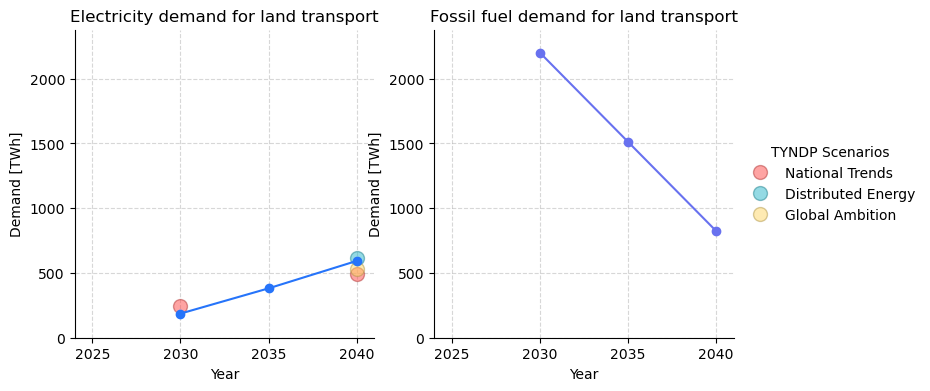

In [207]:
fig, axs = plt.subplots(1, 2, figsize=(8.5, 4))

ylimmax = get_ylimmax([ev_load, ice_load, tyndp_ev_demand]) * 1.08

data_to_plot(axs[0], years, ev_load, tyndp_data=tyndp_ev_demand, title='Electricity demand for land transport', ylabel='Demand [TWh]', ylimmax=ylimmax)
data_to_plot(axs[1], years, ice_load, title='Fossil fuel demand for land transport', ylabel='Demand [TWh]', ylimmax=ylimmax)

add_tyndp_legend(axs)

plt.show()

NameError: name 'n' is not defined

In [208]:
idx = pd.IndexSlice

heating_carriers = pd.Index([
    'urban decentral heat',
    'urban central heat',
    'residential urban decentral heat',
    'residential rural heat',
    'rural heat',
])

tyndp_gas_heating = methane_residential_tertiary(valpath)

In [209]:
indicators = ['gas boiler', 'biomass boiler', 'resistive heater', 'heat pump', 'oil boiler']

def clean_carrier(carrier):
    if len(matches := [ind for ind in indicators if ind in carrier]) > 0:
        return matches[0]
    else:
        return 'other'


data = []

for year in years:
    try:
        eb = ns[year].statistics.energy_balance(groupby=['carrier', 'bus', 'bus_carrier'])
        eb = eb.loc[idx[:, :, all_eu27_buses.intersection(eb.index.get_level_values(2).unique())]]
        eb = eb.groupby(level=[0,1,3]).sum()
        eb = eb.loc[
            idx[:, :, heating_carriers.intersection(eb.index.get_level_values(2).unique())]
            ].sort_values()
    except KeyError:
        continue

    grouper = {
        carrier: clean_carrier(carrier)
        for carrier in eb.index.get_level_values(1)
    }

    eb.index = eb.index.get_level_values(1)
    eb = eb.groupby(grouper).sum().drop('other').mul(1e-6)

    data.append(eb.rename(year))

data = pd.concat([d.to_frame() for d in data], axis=1)

data

,2030,2035,2040
carrier,,,
biomass boiler,230.899952,217.107889,184.956677
gas boiler,1131.963049,924.038376,810.073991
heat pump,961.546306,1187.219013,1235.952447


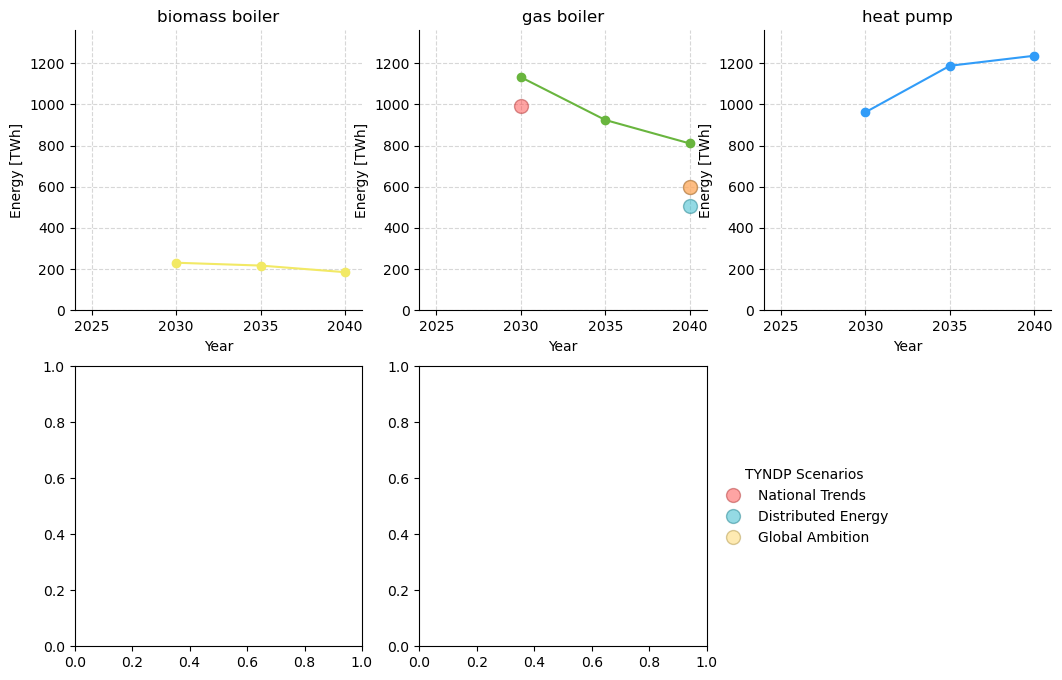

In [210]:
ylimmax = data.max().max() * 1.1

fig, axs = plt.subplots(2, 3, figsize=(3 * 4.2, 8))

for i, (name, row) in enumerate(data.iterrows()):

    ax = axs.flatten()[i]

    if name == 'gas boiler':
        kwargs = {'tyndp_data': tyndp_gas_heating}
    else:
        kwargs = {}

    data_to_plot(ax, row.index, list(row), title=name, ylabel='Energy [TWh]', ylimmax=ylimmax, **kwargs)

axs.flatten()[-1].set_visible(False)
add_tyndp_legend(axs.flatten()[:-1])

plt.show()

In [211]:
industry_loads = [
    'gas for industry',
    'H2 for industry',
    'naphtha for industry',
    'coal for industry',
    'low-temperature heat for industry',
    'industry electricity',
    'solid biomass for industry',
    'industry methanol',
]

data = []

for year in years:

    year_loads = []

    for load in industry_loads:
        index = ns[year].loads.index[(ns[year].loads.carrier == load) & ns[year].loads.bus.isin(all_eu27_buses)]
        
        try:
            year_loads.append(ns[year].loads_t.p_set.loc[:, index].sum().sum() * w * 1e-6)
        except KeyError:
            year_loads.append(ns[year].loads.loc[index, 'p_set'].sum() * w * 1e-6 * len(n.snapshots))

    year_loads = pd.DataFrame({year: year_loads}, index=industry_loads)
    data.append(year_loads)

data = pd.concat(data, axis=1)

In [212]:
def add_dict_leaves(dict1, dict2):
    """Add all leaf nodes of two dicts with the same structure."""
    result = {}
    for key in dict1:
        if isinstance(dict1[key], dict):
            result[key] = add_dict_leaves(dict1[key], dict2[key])
        else:
            result[key] = dict1[key] + dict2[key]
    return result

In [213]:
gas_industry_energetic = methane_industry_energetic(valpath)
gas_industry_nonenergetic = methane_industry_nonenergetic(valpath)
gas_industry = add_dict_leaves(gas_industry_energetic, gas_industry_nonenergetic)
gas_industry

{'National Trends': {2030: 1054.5708898045905, 2040: 710.0269618790448},
 'Distributed Energy': {2040: 559.6370633349316, 2050: 286.3726374181465},
 'Global Ambition': {2040: 676.8503679772065, 2050: 380.9271647444467}}

In [214]:
electricity_industry = final_electricity_industry(valpath)

In [215]:
ylimmax = get_ylimmax([data.values.flatten(), gas_industry, electricity_industry]) * 1.1

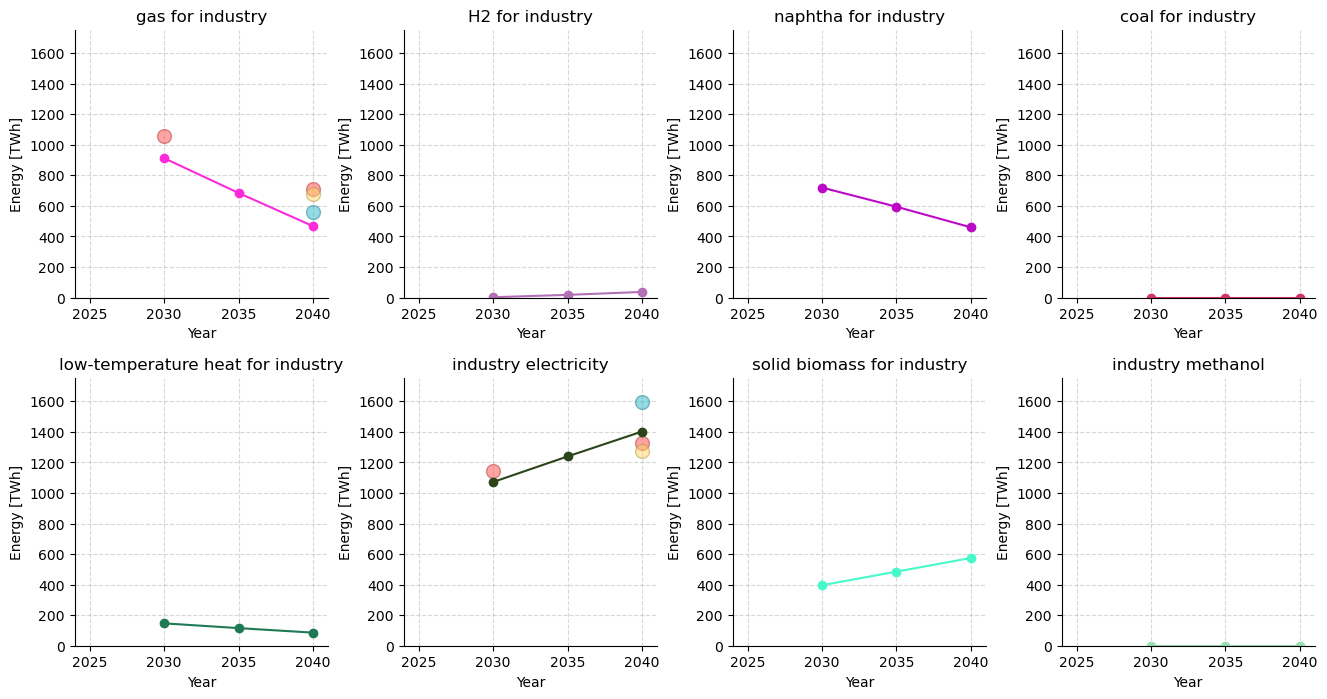

In [216]:
fig, axs = plt.subplots(2, len(industry_loads)//2, figsize=(len(industry_loads)//2 * 4, 8))

for i, (name, row) in enumerate(data.iterrows()):
    ax = axs.flatten()[i]

    if name == 'gas for industry':
        kwargs = {'tyndp_data': gas_industry}
    elif name == 'industry electricity':
        kwargs = {'tyndp_data': electricity_industry}
    else:
        kwargs = {}

    data_to_plot(ax, row.index, list(row), title=name, ylabel='Energy [TWh]', ylimmax=ylimmax, **kwargs)


fig.subplots_adjust(hspace=0.3, wspace=0.3)

plt.show()

In [217]:
cs = n.statistics.optimal_capacity().index.get_level_values(1).unique()
[c for c in cs if 'umped' in c]

['Pumped Hydro Storage']

In [218]:
capacities = {
    'offwind': ['Offshore Wind (AC)', 'Offshore Wind (DC)', 'Offshore Wind (Floating)'],
    'onwind': ['Onshore Wind'],
    'solar': ['Solar', 'solar-hsat'],
    'hydro': ['Run of River', 'Reservoir & Dam'],
    'gas': ['Combined-Cycle Gas', 'Open-Cycle Gas'],
    'coal': ['coal', 'lignite'],
    'nuclear': ['nuclear'],
    'battery': ['Battery Storage'],
    'PHS': ['Pumped Hydro Storage'],
    'electrolyser': ['H2 Electrolysis'],
}

In [219]:
'nuclear' in n.statistics.optimal_capacity().index.get_level_values(1).unique()

True

In [220]:
ns[2040].statistics.optimal_capacity().loc[idx[:, 'battery charger']]

component
Link    3.06929
dtype: float64

In [223]:
m = ns[2040]

In [224]:
print(n.statistics.optimal_capacity().shape)
n.statistics.optimal_capacity().head()

(95,)


component    carrier             
Line         AC                      573055.35111
StorageUnit  Pumped Hydro Storage     55810.13555
             Reservoir & Dam         103308.66528
Link         BEV charger             706713.75572
             CO2 pipeline               223.63443
dtype: float64

In [225]:
ss = n.statistics.optimal_capacity(groupby=['carrier', 'bus'])
print(ss.head())
print(ss.loc[idx[:, 'coal', :]])
ss = ss.loc[idx[:, :, ss.index.get_level_values(2).isin(all_eu27_buses.tolist() + ['EU coal', 'EU lignite', 'EU uranium', 'EU gas'])]]
ss = ss.groupby(level=[0, 1]).sum()
print(ss.shape)
ss.head()

component  carrier  bus  
Line       AC       AL0 0     9741.75134
                    AT0 0    35168.60838
                    BA0 0    16757.59634
                    BE0 0    14646.13503
                    BG0 0    15908.54503
dtype: float64
component  bus    
Store      EU coal    15292.78613
Generator  EU coal    43280.95205
dtype: float64
(80,)


component  carrier                 
Generator  Offshore Wind (AC)           96464.66239
           Offshore Wind (DC)            2370.96708
           Offshore Wind (Floating)      2346.30067
           Onshore Wind                341360.04347
           Run of River                 37089.27323
dtype: float64

In [234]:
caps = ns[year].statistics.optimal_capacity(groupby=['carrier', 'bus'])
caps = caps.groupby(level=[0, 1]).sum()
caps.loc[idx[:, 'home battery charger']]

component
Link    2.15173
dtype: float64

In [239]:
m = ns[year]
# m.stores.loc[m.stores.carrier == 'home battery', 'e_nom']
m.links.loc[m.links.carrier == 'home battery charger', ['p_nom', 'p_nom_extendable', 'p_nom_opt']]

,p_nom,p_nom_extendable,p_nom_opt
Link,,,
AL0 0 home battery charger,0.000000,True,0.042136
AT0 0 home battery charger,74.023016,True,0.041352
BA0 0 home battery charger,0.000000,True,0.040119
BE0 0 home battery charger,626.878521,True,0.042279
BG0 0 home battery charger,635.935746,True,0.040444
CH0 0 home battery charger,1111.808687,True,0.043467
CZ0 0 home battery charger,451.163371,True,0.039875
DE0 0 home battery charger,63058.134728,True,0.044748
DE0 1 home battery charger,63058.134728,True,0.043943


In [226]:
gas_capacity = gas_power_capacity_mix(valpath)
solar_capacity = solar_power_capacity_mix(valpath)
onwind_capacity = wind_onshore_power_capacity_mix(valpath)
offwind_capacity = wind_offshore_power_capacity_mix(valpath)
nuclear_capacity = nuclear_power_capacity_mix(valpath)
battery_capacity = battery_power_capacity_mix(valpath)

data = []

for year in years:

    year_caps = []
    
    caps = ns[year].statistics.optimal_capacity(groupby=['carrier', 'bus'])
    # caps = caps.loc[idx[:, :, caps.index.get_level_values(2).isin(all_eu27_buses.tolist() + ['EU coal', 'EU lignite', 'EU uranium', 'EU gas'])]]
    caps = caps.groupby(level=[0, 1]).sum()

    for name, carriers in capacities.items():
        
        if name in ['coal', 'gas']:
            carriers = caps.loc[idx['Link']].index.intersection(carriers)
            year_caps.append(caps.loc[idx['Link', carriers]].sum() * 1e-3)
        elif name in ['nuclear']:
            year_caps.append(caps.loc[idx['Generator', carriers]].sum() * 1e-3)
        else:
            year_caps.append(caps.loc[idx[:, carriers]].sum() * 1e-3)

    year_caps = pd.DataFrame({year: year_caps}, index=capacities.keys())
    data.append(year_caps)

data = pd.concat(data, axis=1)
data


,2030,2035,2040
offwind,156.098191,263.578979,371.991558
onwind,385.894793,463.690565,542.644956
solar,671.590982,899.843230,1129.204280
hydro,151.112994,151.112994,151.112994
gas,73.936283,79.879808,91.079707
coal,0.000000,0.000000,0.000000
nuclear,101.795197,106.371017,110.946837
battery,0.004532,0.003547,0.002803
PHS,55.810136,55.810136,55.810136
electrolyser,0.000906,5.226846,37.480198


In [227]:
ylimmax = get_ylimmax([
    data.values.flatten(),
    gas_capacity,
    solar_capacity,
    onwind_capacity,
    offwind_capacity,
    nuclear_capacity,
    battery_capacity
    ]) * 1.1

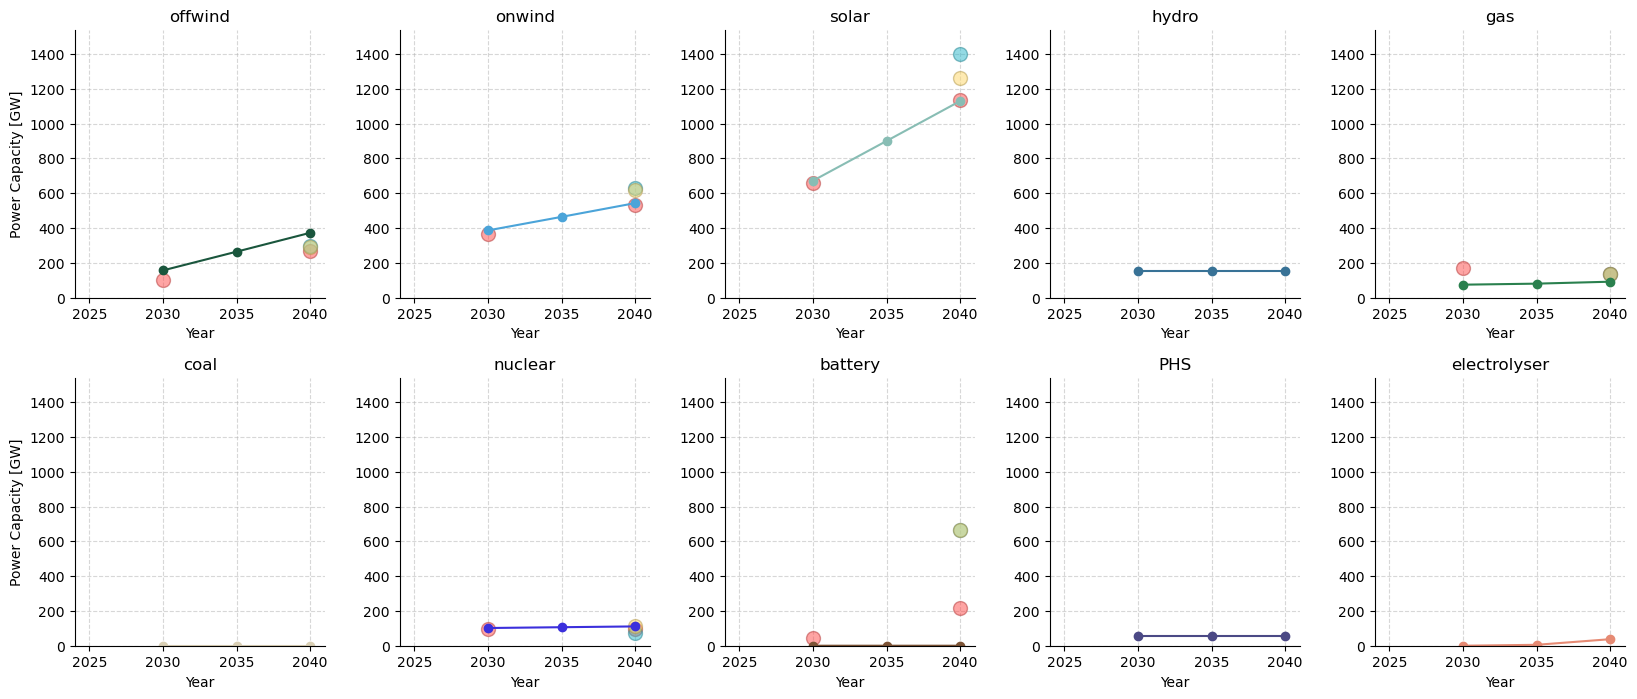

In [228]:
fig, axs = plt.subplots(2, len(capacities)//2, figsize=(len(capacities)//2 * 4, 8))

for i, (name, row) in enumerate(data.iterrows()):
    ax = axs.flatten()[i]

    if name+'_capacity' in globals():
        kwargs = {'tyndp_data': globals()[name+'_capacity']}
    else:
        kwargs = {}
    
    data_to_plot(ax, row.index, list(row), title=name, ylimmax=ylimmax, **kwargs)

for ax in axs[:,0]:
    ax.set_ylabel('Power Capacity [GW]')

fig.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

In [113]:
n.stores.carrier.unique()

array(['co2 stored', 'co2 sequestered', 'gas', 'H2 Store', 'battery',
       'EV battery', 'oil', 'ammonia store', 'methanol',
       'non-sequestered HVC', 'coal', 'home battery'], dtype=object)

In [192]:
n.stores.loc[n.stores.carrier == 'battery', ['capital_cost', 'marginal_cost', 'bus']].head()

,capital_cost,marginal_cost,bus
Store,,,
AL0 0 battery,17805.062352,0.009842,AL0 0 battery
AT0 0 battery,17805.062352,0.009760,AT0 0 battery
BA0 0 battery,17805.062352,0.009343,BA0 0 battery
BE0 0 battery,17805.062352,0.009312,BE0 0 battery
BG0 0 battery,17805.062352,0.009346,BG0 0 battery


In [119]:
n.links.loc[n.links.carrier == 'battery charger', ['capital_cost', 'marginal_cost', 'bus0', 'bus1']].head()

,capital_cost,marginal_cost,bus0,bus1
Link,,,,
AL0 0 battery charger,33126.231898,0.010944,AL0 0,AL0 0 battery
AT0 0 battery charger,33126.231898,0.010975,AT0 0,AT0 0 battery
BA0 0 battery charger,33126.231898,0.009817,BA0 0,BA0 0 battery
BE0 0 battery charger,33126.231898,0.010312,BE0 0,BE0 0 battery
BG0 0 battery charger,33126.231898,0.009811,BG0 0,BG0 0 battery


In [120]:
n.stores.loc[n.stores.carrier == 'home battery', ['capital_cost', 'marginal_cost', 'bus']].head()

,capital_cost,marginal_cost,bus
Store,,,
AL0 0 home battery,25210.086855,0.009845,AL0 0 home battery
AT0 0 home battery,25210.086855,0.010324,AT0 0 home battery
BA0 0 home battery,25210.086855,0.010600,BA0 0 home battery
BE0 0 home battery,25210.086855,0.010531,BE0 0 home battery
BG0 0 home battery,25210.086855,0.010633,BG0 0 home battery


In [122]:
n.links.loc[n.links.carrier == 'home battery charger', ['capital_cost', 'marginal_cost', 'bus0', 'bus1']].head()

,capital_cost,marginal_cost,bus0,bus1
Link,,,,
AL0 0 home battery charger,46777.155776,0.010108,AL0 0 low voltage,AL0 0 home battery
AT0 0 home battery charger,46777.155776,0.009356,AT0 0 low voltage,AT0 0 home battery
BA0 0 home battery charger,46777.155776,0.010401,BA0 0 low voltage,BA0 0 home battery
BE0 0 home battery charger,46777.155776,0.010563,BE0 0 low voltage,BE0 0 home battery
BG0 0 home battery charger,46777.155776,0.010269,BG0 0 low voltage,BG0 0 home battery


In [121]:
battery_buses = n.stores.loc[n.stores.carrier == 'home battery', 'bus']
n.links.loc[n.links.bus0.isin(battery_buses) | n.links.bus1.isin(battery_buses)]

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,location,reversed,underground,tags,voltage,project_status,under_construction,dc,underwater_fraction,geometry
Link,,,,,,,,,,,,,,,,,,,,,
AL0 0 home battery charger,AL0 0 low voltage,AL0 0 home battery,,home battery charger,0.977241,True,0,10.0,0.0,0.0,...,,False,NaN,,NaN,,NaN,NaN,NaN,
AT0 0 home battery charger,AT0 0 low voltage,AT0 0 home battery,,home battery charger,0.977241,True,0,10.0,0.0,0.0,...,,False,NaN,,NaN,,NaN,NaN,NaN,
BA0 0 home battery charger,BA0 0 low voltage,BA0 0 home battery,,home battery charger,0.977241,True,0,10.0,0.0,0.0,...,,False,NaN,,NaN,,NaN,NaN,NaN,
BE0 0 home battery charger,BE0 0 low voltage,BE0 0 home battery,,home battery charger,0.977241,True,0,10.0,0.0,0.0,...,,False,NaN,,NaN,,NaN,NaN,NaN,
BG0 0 home battery charger,BG0 0 low voltage,BG0 0 home battery,,home battery charger,0.977241,True,0,10.0,0.0,0.0,...,,False,NaN,,NaN,,NaN,NaN,NaN,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RS0 0 home battery discharger,RS0 0 home battery,RS0 0 low voltage,,home battery discharger,0.977241,True,0,10.0,0.0,0.0,...,,False,NaN,,NaN,,NaN,NaN,NaN,
SE1 0 home battery discharger,SE1 0 home battery,SE1 0 low voltage,,home battery discharger,0.977241,True,0,10.0,0.0,0.0,...,,False,NaN,,NaN,,NaN,NaN,NaN,
SI0 0 home battery discharger,SI0 0 home battery,SI0 0 low voltage,,home battery discharger,0.977241,True,0,10.0,0.0,0.0,...,,False,NaN,,NaN,,NaN,NaN,NaN,


In [ ]:
print(ns[year].statistics.supply().shape)
ns[year].statistics.supply().head()

(104,)


component  carrier                 
Generator  Offshore Wind (AC)          1.721941e+08
           Offshore Wind (DC)          1.809979e+08
           Offshore Wind (Floating)    1.304670e+02
           Onshore Wind                1.071675e+09
           Run of River                1.625157e+08
dtype: float64

In [395]:
ss = ns[year].statistics.supply(groupby=['carrier', 'bus']).loc[idx[:, :, eu27_buses]]

In [ ]:
'Battery Storage' in ns[year].statistics.supply().index.get_level_values(1).unique()

True

In [403]:
ns[year].statistics.supply().loc[idx[:, 'Battery Storage']]


component
Store    2.588
dtype: float64

In [ ]:
ss = ss.groupby(level=[0, 1]).sum()
print(ss.shape)
ss

(25,)


component    carrier                           
Generator    Offshore Wind (AC)                    1.076924e+08
             Offshore Wind (DC)                    1.809972e+08
             Offshore Wind (Floating)              9.856097e+01
             Onshore Wind                          7.470139e+08
             Run of River                          1.335754e+08
             Solar                                 6.510533e+08
             nuclear                               5.009901e+08
             solar-hsat                            7.222388e+08
Line         AC                                    1.036139e+09
Link         Combined-Cycle Gas                    1.309179e+08
             DC                                    1.251430e+08
             OCGT methanol                         2.927839e+01
             Open-Cycle Gas                        1.426378e+06
             battery discharger                    2.300262e+03
             coal                                  8.969

In [405]:
gas_mix = gas_power_generation_mix(valpath)
solar_mix = solar_power_generation_mix(valpath)
onwind_mix = wind_onshore_power_generation_mix(valpath)
offwind_mix = wind_offshore_power_generation_mix(valpath)
nuclear_mix = nuclear_power_generation_mix(valpath)
battery_mix = battery_power_generation_mix(valpath)

data = []

for year in years:

    year_mix = []
    # mixes = ns[year].statistics.supply()
    mixes = ns[year].statistics.supply(groupby=['carrier', 'bus']).loc[idx[:, :, eu27_buses]]
    mixes = mixes.groupby(level=[0, 1]).sum()

    for name, carriers in capacities.items():

        if name == 'battery' or name == 'electrolyser':
            year_mix.append(0)
            continue


        if name in ['coal', 'gas']:
            year_mix.append(mixes.loc[idx['Link', carriers]].sum() * 1e-6)
        else:
            year_mix.append(mixes.loc[idx[:, carriers]].sum() * 1e-6)

    year_mix = pd.DataFrame({year: year_mix}, index=capacities.keys())
    data.append(year_mix)


data = pd.concat(data, axis=1)
data

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035
offwind,183.732995,192.287923,204.522768,211.139885,219.496869,226.440383,234.099026,249.683496,267.395055,275.584359,288.689656
onwind,590.919807,609.336870,625.076624,639.715962,650.672591,684.914285,714.479582,731.673627,738.178049,742.667937,747.013888
solar,881.795340,924.020201,955.239575,985.081517,1027.515443,1103.387425,1159.640362,1210.637892,1253.298744,1317.925599,1373.292051
hydro,303.505252,303.506446,303.509701,303.510042,303.510071,303.505741,303.509687,303.509940,303.510423,303.510861,303.510495
gas,73.655280,82.747174,89.048251,81.908051,98.939718,94.335150,103.682641,111.922150,104.839332,120.496352,132.344238
coal,232.379327,204.895247,195.174310,179.345482,159.225961,135.616153,116.879231,111.057782,104.443631,93.092710,91.320812
nuclear,538.461063,536.998382,537.359162,537.602685,537.130765,515.982043,512.259452,509.140849,509.120046,504.967408,500.990146
battery,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
PHS,11.924088,11.648261,11.442296,11.508942,11.345427,11.650191,12.322098,12.550412,12.215451,11.591056,12.485210
electrolyser,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [406]:
ylimmax = get_ylimmax([
    data.values.flatten(),
    gas_mix,
    solar_mix,
    onwind_mix,
    offwind_mix,
    nuclear_mix,
    battery_mix
    ]) * 1.1

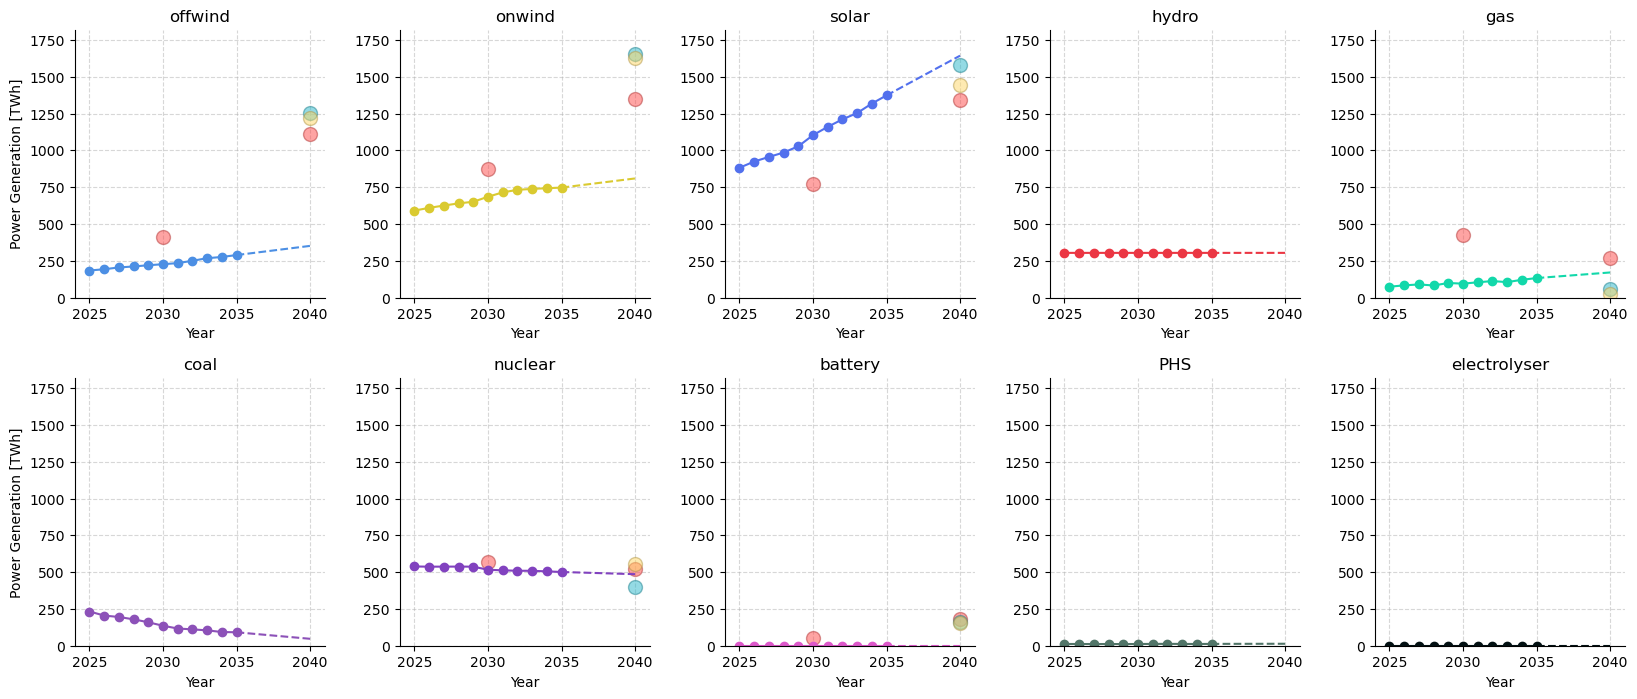

In [407]:
fig, axs = plt.subplots(2, len(capacities)//2, figsize=(len(capacities)//2 * 4, 8))

for i, (name, row) in enumerate(data.iterrows()):
    ax = axs.flatten()[i]

    if name+'_mix' in globals():
        kwargs = {'tyndp_data': globals()[name+'_mix']}
    else:
        kwargs = {}
    
    data_to_plot(ax, row.index, list(row), title=name, ylimmax=ylimmax, **kwargs)

for ax in axs[:,0]:
    ax.set_ylabel('Power Generation [TWh]')

fig.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

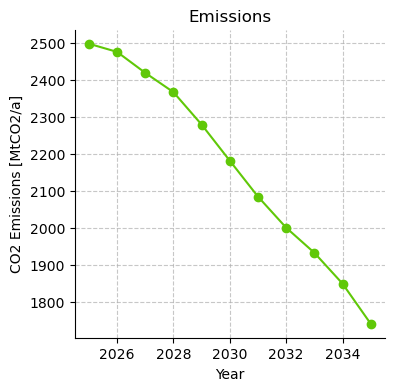

In [211]:
gens = n.generators.index[n.generators.carrier == 'co2-ets']

emissions = []

for year in years:
    emissions.append(ns[year].generators_t.p.loc[:, gens].sum().sum() * w * -1e-6)

emissions = pd.DataFrame({'emissions': emissions}, index=years)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

emissions['emissions'].plot(ax=ax, marker='o', color=np.random.rand(3,))
ax.set_title('Emissions')

ax.grid(True, linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel('Year')

ax.set_ylabel('CO2 Emissions [MtCO2/a]')

plt.show()

In [3]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

In [4]:
with PdfPages("my_plots.pdf") as pdf:
    # --- First figure ---
    fig, ax = plt.subplots()
    ax.plot([1, 2, 3], [1, 4, 9])
    ax.set_title("First plot")
    pdf.savefig(fig)   # saves the current figure into the PDF
    plt.close(fig)

    # --- Second figure ---
    fig, ax = plt.subplots()
    ax.plot([1, 2, 3], [2, 3, 5])
    ax.set_title("Second plot")
    pdf.savefig(fig)
    plt.close(fig)

In [1]:
import pandas as pd

def select_supply_scenario(df: pd.DataFrame, scenario: str) -> pd.DataFrame:
    """
    Parameters
    ----------
    df : DataFrame
        Index: countries
        Columns: MultiIndex (carrier, band) where
                 carrier ∈ {onwind, offwind, solar, battery, nuclear}
                 band    ∈ {LOW, NT, HIGH}
    scenario : str
        'NT', 'DE' or 'GA' (case-insensitive).

    Returns
    -------
    DataFrame
        Columns are the carriers only (first level), with the
        appropriate band selected per carrier.
    """

    scenario = scenario.upper()

    # mapping: scenario -> {carrier -> band}
    band_map = {
        "NT": {
            "onwind": "NT",
            "offwind": "NT",
            "solar": "NT",
            "battery": "NT",
            "nuclear": "NT",
        },
        "DE": {
            "onwind": "HIGH",
            "offwind": "NT",
            "solar": "HIGH",
            "battery": "HIGH",
            "nuclear": "LOW",
        },
        "GA": {
            "onwind": "NT",
            "offwind": "HIGH",
            "solar": "NT",
            "battery": "NT",
            "nuclear": "HIGH",
        },
    }

    if scenario not in band_map:
        raise ValueError(f"Unknown scenario '{scenario}', expected one of {list(band_map)}")

    # For the simple NT case, we can shortcut using xs on level=1
    if scenario == "NT":
        # assumes level 1 is the band and contains 'NT'
        return df.xs("NT", axis=1, level=1)

    # For DE / GA: pick the appropriate band per carrier
    mapping = band_map[scenario]

    # Build a new dataframe with columns = carriers only
    out = {}
    for carrier, band in mapping.items():
        out[carrier] = df[(carrier, band)]

    # concat along columns; keys become the carrier names as top-level columns
    out_df = pd.concat(out, axis=1)
    # out_df.columns is already just the carriers (because we passed a dict)
    return out_df


In [2]:
import pandas as pd
from pathlib import Path

df = pd.read_csv(Path.cwd().parent / 'resources' / 'tyndp_capacities_2035.csv', index_col=0, header=[0, 1])

In [5]:
df.head()

onwind                        offwind                         solar  \
            LOW            NT     HIGH     LOW      NT         HIGH      LOW   
AL   440.000000    440.000000    440.0     0.0     0.0     0.000000    900.0   
AT  7500.000417  12500.001001  22017.5     0.0     0.0     0.000000  12000.0   
BA  1151.600000   1151.600000   1151.6     0.0     0.0     0.000000    882.3   
BE  5700.000000   6376.476562   7375.0  6860.0  6860.0  6860.000000  15500.0   
BG  1000.000000   1379.500000   2759.0     0.0     0.0   149.283439   2750.0   

                          battery                       nuclear          \
              NT     HIGH     LOW      NT          HIGH     LOW      NT   
AL    900.000000    900.0     0.0     0.0    640.545651     0.0     0.0   
AT  21000.257000  41000.0   229.8   229.8    437.261289     0.0     0.0   
BA    882.300000    882.3     0.0     0.0    634.060740     0.0     0.0   
BE  19947.636766  25000.0  2148.0  2148.0  20978.000000  1038.5  1038.5   
BG   3732.737000   7465.0  6000.0  6000.0  12508.974683  2000.0  3000.0   

            
      HIGH  
AL     0.0  
AT     0.0  
BA     0.0  
BE  1038.5  
BG  3000.0

In [7]:
select_supply_scenario(df, 'GA').head()

,onwind,offwind,solar,battery,nuclear
AL,440.000000,0.000000,900.000000,0.0,0.0
AT,12500.001001,0.000000,21000.257000,229.8,0.0
BA,1151.600000,0.000000,882.300000,0.0,0.0
BE,6376.476562,6860.000000,19947.636766,2148.0,1038.5
BG,1379.500000,149.283439,3732.737000,6000.0,3000.0


In [33]:
n = pypsa.Network(
    # Path.cwd().parent / 'resources' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2025.nc'
    Path.cwd().parent / 'resources' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_brownfield.nc'
)

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_brownfield.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [34]:
n.generators.carrier.unique()

array(['nuclear', 'onwind', 'solar', 'offwind-float', 'offwind-ac',
       'solar-hsat', 'offwind-dc', 'ror', 'lignite', 'coal',
       'oil primary', 'gas', 'urban central heat vent',
       'urban central solar thermal', 'biogas', 'solid biomass',
       'unsustainable biogas', 'unsustainable solid biomass',
       'unsustainable bioliquids', 'solar rooftop', 'rural heat vent',
       'rural solar thermal', 'urban decentral heat vent',
       'urban decentral solar thermal', 'co2-ets'], dtype=object)

In [12]:
idx = pd.IndexSlice
n.statistics.energy_balance().loc[idx[:, 'nuclear', :]]

component  bus_carrier
Link       AC             3.970000e-02
           uranium       -1.217700e-01
Generator  AC             6.048891e+08
dtype: float64

In [164]:
import pypsa
from pathlib import Path

n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2035_NT_0.04.nc'
)

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2035_NT_0.04.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [170]:
idx = pd.IndexSlice
tot = n.statistics.energy_balance().loc[idx['Generator', 'gas', :]].iloc[0] / 1e6
print('Total gas used: {:.2f} TWh'.format(tot))

Total gas used: 2599.23 TWh


In [174]:
n.links.loc[n.links.bus0.str.contains('gas')].carrier.unique()

array(['OCGT', 'CCGT', 'gas pipeline', 'gas pipeline new', 'SMR CC',
       'SMR', 'urban central gas boiler', 'urban central gas CHP',
       'urban central gas CHP CC', 'biogas to gas', 'gas for industry',
       'gas for industry CC', 'rural gas boiler',
       'urban decentral gas boiler'], dtype=object)

In [ ]:
gas_power_plants = n.links.index[n.links.carrier.isin(['OCGT', 'CCGT'])]
power_sector_consumption = n.links_t.p0[gas_power_plants].mul(n.snapshot_weightings.generators, axis=0).sum().sum() / 1e6
print('Power sector consumption: {:.2f} TWh'.format(power_sector_consumption))

Power sector consumption: 255.24 TWh


In [ ]:
gas_boilers = n.links.index[n.links.carrier.str.contains('gas boiler')]
heating_sector_consumption = n.links_t.p0[gas_boilers].mul(n.snapshot_weightings.generators, axis=0).sum().sum() / 1e6
print('Heating sector consumption: {:.2f} TWh'.format(heating_sector_consumption))

Heating sector consumption: 666.64 TWh


In [ ]:
sector_grouping = {
    'Combined-Cycle Gas': 'power',
    'Open-Cycle Gas': 'power',
    'SMR': 'industry',
    'SMR CC': 'industry',
    'gas for industry': 'industry',
    'gas for industry CC': 'industry',
    'rural gas boiler': 'heating',
    'urban central gas CHP': 'heating',
    'urban central gas CHP CC': 'heating',
    'urban central gas boiler': 'heating',
    'urban decentral gas boiler': 'heating'
}

eb = n.statistics.energy_balance().loc[idx[:, :, 'gas']] / 1e6
eb.index = eb.index.droplevel(0)
eb.groupby(sector_grouping).sum().mul(-1)


carrier
heating     1145.997463
industry    1263.274706
power        255.242187
dtype: float64

In [192]:
n.statistics()[['Capital Expenditure', 'Operational Expenditure']].sum().sum()

950655175219.6545

In [ ]:
n.objective

603757514757.4905